### Trabalho 3 MAI5001 - MECAI USP
### Autores: 
### Eduardo Brito - 14470853
### Junior
### ...
### ...
### Data: 22/11/2025


Executando simulação para N = 10 produtos...
Inspeção Tipo 1: N=10, operações=134
Inspeção Tipo 2: N=10, operações=52199
Controle (hash): N=10, operações de inserção=10

Executando simulação para N = 100 produtos...
Inspeção Tipo 1: N=100, operações=1348
Inspeção Tipo 2: N=100, operações=493398
Controle (hash): N=100, operações de inserção=100

Executando simulação para N = 1000 produtos...
Inspeção Tipo 1: N=1000, operações=13490
Inspeção Tipo 2: N=1000, operações=5229358
Controle (hash): N=1000, operações de inserção=1000

Executando simulação para N = 5000 produtos...
Inspeção Tipo 1: N=5000, operações=66779
Inspeção Tipo 2: N=5000, operações=24933674
Controle (hash): N=5000, operações de inserção=5000

Executando simulação para N = 10000 produtos...
Inspeção Tipo 1: N=10000, operações=133735
Inspeção Tipo 2: N=10000, operações=49609850
Controle (hash): N=10000, operações de inserção=10000


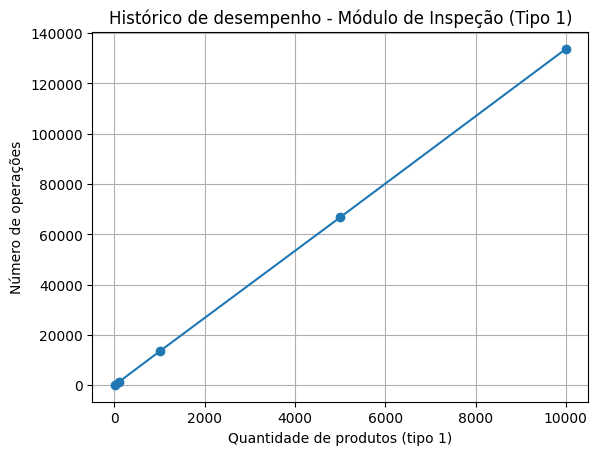

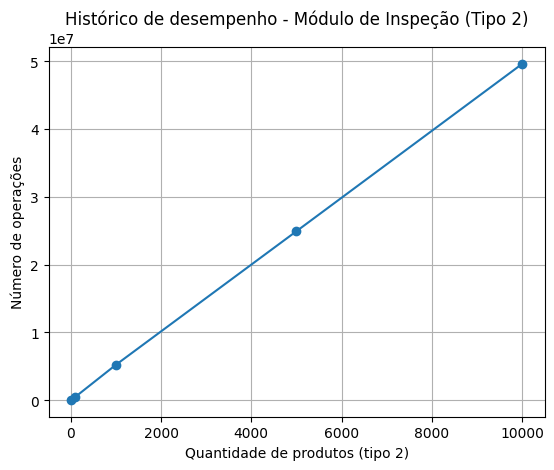

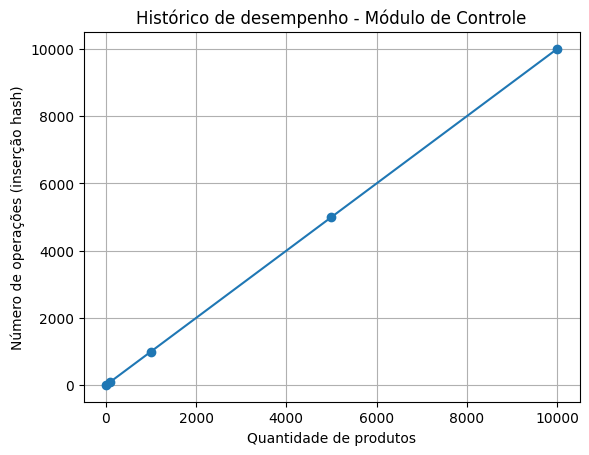

In [4]:
import random
import string
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

import matplotlib.pyplot as plt


# =========================
# MODELO DE DADOS
# =========================

@dataclass
class Produto:
    chave_cliente: str
    tipo_produto: int   # 1 ou 2
    tamanho: int        # n
    tempo_inspecao: Optional[int] = None  # preenchido pelo Módulo de Inspeção


# =========================
# GERADOR DE DADOS
# =========================

class GeradorDados:
    def gerar_chave_cliente(self) -> str:
        # Ex.: C123
        return "C" + ''.join(random.choices(string.digits, k=3))

    def gerar_produtos_tipo(self, qtd: int, tipo: int,
                            min_tam: int = 10, max_tam: int = 10000) -> List[Produto]:
        produtos = []
        for _ in range(qtd):
            chave = self.gerar_chave_cliente()
            tamanho = random.randint(min_tam, max_tam)
            produtos.append(
                Produto(chave_cliente=chave,
                        tipo_produto=tipo,
                        tamanho=tamanho)
            )
        return produtos

    def gerar_produtos_mistos(self, qtd: int,
                              min_tam: int = 10, max_tam: int = 10000) -> List[Produto]:
        produtos = []
        for _ in range(qtd):
            chave = self.gerar_chave_cliente()
            tipo = random.choice([1, 2])
            tamanho = random.randint(min_tam, max_tam)
            produtos.append(
                Produto(chave_cliente=chave,
                        tipo_produto=tipo,
                        tamanho=tamanho)
            )
        return produtos


# =========================
# MÓDULO DE INSPEÇÃO
# =========================

class ModuloInspecao:
    """
    Implementa os dois tipos de inspeção e conta número de operações
    para análise de complexidade.
    """

    def __init__(self):
        self.ops_tipo1 = 0
        self.ops_tipo2 = 0

    def reset_ops(self):
        self.ops_tipo1 = 0
        self.ops_tipo2 = 0

    def _tempo_inspecao_tipo1(self, n: int) -> int:
        """
        Tipo 1:
        - 1h preparação do produto de tamanho n
        - 1h para inspecionar a metade
        - repete dividindo por 2 até n = 1 (inteiro)
        - em n = 1, mais 1h de inspeção
        Complexidade esperada: O(log n)
        """
        tempo_total = 0

        # preparação inicial
        tempo_total += 1
        self.ops_tipo1 += 1  # conta preparação

        tamanho_atual = n
        while tamanho_atual > 1:
            tamanho_atual //= 2  # metade inteira
            tempo_total += 1
            self.ops_tipo1 += 1  # conta inspeção dessa "metade"

        # inspeção final em tamanho 1
        tempo_total += 1
        self.ops_tipo1 += 1

        return tempo_total

    def _tempo_inspecao_tipo2(self, n: int) -> int:
        """
        Tipo 2:
        - n + (n-1) + ... + 1 horas
        Complexidade esperada: O(n)
        """
        tempo_total = 0
        tamanho_atual = n
        while tamanho_atual >= 1:
            tempo_total += tamanho_atual
            tamanho_atual -= 1
            self.ops_tipo2 += 1  # conta uma iteração
        return tempo_total

    def inspecionar_produto(self, produto: Produto) -> Produto:
        if produto.tipo_produto == 1:
            produto.tempo_inspecao = self._tempo_inspecao_tipo1(produto.tamanho)
        elif produto.tipo_produto == 2:
            produto.tempo_inspecao = self._tempo_inspecao_tipo2(produto.tamanho)
        else:
            raise ValueError(f"Tipo de produto inválido: {produto.tipo_produto}")
        return produto

    def processar_lote(self, produtos: List[Produto]) -> List[Produto]:
        """
        Processa um lote de produtos (tipos mistos ou não),
        preenchendo tempo_inspecao e ordenando pelo tempo.
        """
        for p in produtos:
            self.inspecionar_produto(p)

        produtos_ordenados = sorted(produtos, key=lambda p: p.tempo_inspecao)
        return produtos_ordenados


# =========================
# MÓDULO DE CONTROLE (TABELA HASH)
# =========================

class ModuloControle:
    """
    Usa tabela hash com m buckets.
    Chave de armazenamento: (chave_cliente, tamanho_produto).
    Complexidade esperada:
        - Inserção: O(1) média
        - Busca:    O(1) média
    """

    def __init__(self, m: int = 101):
        # m primo ajuda a dispersar melhor
        self.m = m
        self.buckets: List[Dict[Tuple[str, int], Produto]] = [dict() for _ in range(m)]
        self.ops_insercao = 0
        self.ops_busca = 0

    def reset(self):
        self.buckets = [dict() for _ in range(self.m)]
        self.ops_insercao = 0
        self.ops_busca = 0

    def _indice_bucket(self, chave_cliente: str) -> int:
        # usa hash padrão do Python, depois módulo m
        return hash(chave_cliente) % self.m

    def inserir(self, produto: Produto) -> None:
        if produto.tempo_inspecao is None:
            raise ValueError("Produto ainda não inspecionado (tempo_inspecao = None).")

        idx = self._indice_bucket(produto.chave_cliente)
        chave = (produto.chave_cliente, produto.tamanho)

        # Contamos 1 operação por inserção (hash + acesso ao bucket)
        self.ops_insercao += 1
        self.buckets[idx][chave] = produto

    def inserir_lote(self, produtos: List[Produto]) -> None:
        for p in produtos:
            self.inserir(p)

    def buscar(self, chave_cliente: str, tamanho: int) -> Optional[int]:
        idx = self._indice_bucket(chave_cliente)
        chave = (chave_cliente, tamanho)
        self.ops_busca += 1  # hash + acesso ao bucket

        produto = self.buckets[idx].get(chave)
        if produto is not None:
            return produto.tempo_inspecao
        return None

    def buscar_lote(self, consultas: List[Tuple[str, int]]) -> List[Optional[int]]:
        resultados = []
        for chave, tamanho in consultas:
            resultados.append(self.buscar(chave, tamanho))
        return resultados


# =========================
# MÓDULO DE MONITORAMENTO
# =========================

class ModuloMonitoramento:
    """
    Guarda histórico (N, operações) para:
    - inspeção tipo 1
    - inspeção tipo 2
    - módulo de controle
    e gera 3 gráficos separados.
    """

    def __init__(self):
        self.historico_inspecao_tipo1: List[Tuple[int, int]] = []
        self.historico_inspecao_tipo2: List[Tuple[int, int]] = []
        self.historico_controle: List[Tuple[int, int]] = []

    def registrar_inspecao(self, tipo_produto: int, qtd_produtos: int, ops: int):
        if tipo_produto == 1:
            self.historico_inspecao_tipo1.append((qtd_produtos, ops))
        elif tipo_produto == 2:
            self.historico_inspecao_tipo2.append((qtd_produtos, ops))

    def registrar_controle(self, qtd_produtos: int, ops: int):
        self.historico_controle.append((qtd_produtos, ops))

    def gerar_graficos(self):
        # Gráfico 1 – inspeção tipo 1
        if self.historico_inspecao_tipo1:
            xs, ys = zip(*self.historico_inspecao_tipo1)
            plt.figure()
            plt.plot(xs, ys, marker="o")
            plt.xlabel("Quantidade de produtos (tipo 1)")
            plt.ylabel("Número de operações")
            plt.title("Histórico de desempenho - Módulo de Inspeção (Tipo 1)")
            plt.grid(True)

        # Gráfico 2 – inspeção tipo 2
        if self.historico_inspecao_tipo2:
            xs, ys = zip(*self.historico_inspecao_tipo2)
            plt.figure()
            plt.plot(xs, ys, marker="o")
            plt.xlabel("Quantidade de produtos (tipo 2)")
            plt.ylabel("Número de operações")
            plt.title("Histórico de desempenho - Módulo de Inspeção (Tipo 2)")
            plt.grid(True)

        # Gráfico 3 – módulo de controle
        if self.historico_controle:
            xs, ys = zip(*self.historico_controle)
            plt.figure()
            plt.plot(xs, ys, marker="o")
            plt.xlabel("Quantidade de produtos")
            plt.ylabel("Número de operações (inserção hash)")
            plt.title("Histórico de desempenho - Módulo de Controle")
            plt.grid(True)

        plt.show()


# =========================
# ORQUESTRADOR / SIMULADOR
# =========================

class SimuladorSistema:
    """
    Orquestra:
    - geração de dados
    - inspeção
    - controle
    - monitoramento

    Para cada N em uma lista de tamanhos:
    1) Gera N produtos só tipo 1 → mede operações de inspeção.
    2) Gera N produtos só tipo 2 → idem.
    3) Gera N produtos mistos → inspeciona e insere na tabela hash → mede ops de controle.
    """

    def __init__(self):
        self.gerador = GeradorDados()
        self.inspecao = ModuloInspecao()
        self.controle = ModuloControle(m=101)
        self.monitoramento = ModuloMonitoramento()

    def executar_experimentos(self, tamanhos_listas: List[int]):
        for qtd in tamanhos_listas:
            print("\n" + "=" * 60)
            print(f"Executando simulação para N = {qtd} produtos...")

            # -----------------------------
            # 1) Só produtos tipo 1
            # -----------------------------
            produtos_tipo1 = self.gerador.gerar_produtos_tipo(qtd, tipo=1)
            self.inspecao.reset_ops()
            self.inspecao.processar_lote(produtos_tipo1)
            ops1 = self.inspecao.ops_tipo1
            self.monitoramento.registrar_inspecao(1, qtd, ops1)
            print(f"Inspeção Tipo 1: N={qtd}, operações={ops1}")

            # -----------------------------
            # 2) Só produtos tipo 2
            # -----------------------------
            produtos_tipo2 = self.gerador.gerar_produtos_tipo(qtd, tipo=2)
            self.inspecao.reset_ops()
            self.inspecao.processar_lote(produtos_tipo2)
            ops2 = self.inspecao.ops_tipo2
            self.monitoramento.registrar_inspecao(2, qtd, ops2)
            print(f"Inspeção Tipo 2: N={qtd}, operações={ops2}")

            # -----------------------------
            # 3) Módulo de controle com produtos mistos
            # -----------------------------
            produtos_mistos = self.gerador.gerar_produtos_mistos(qtd)
            self.inspecao.reset_ops()
            produtos_inspecionados = self.inspecao.processar_lote(produtos_mistos)

            self.controle.reset()
            self.controle.inserir_lote(produtos_inspecionados)
            ops_controle = self.controle.ops_insercao
            self.monitoramento.registrar_controle(qtd, ops_controle)
            print(f"Controle (hash): N={qtd}, operações de inserção={ops_controle}")

        # Ao final, gera os 3 gráficos
        self.monitoramento.gerar_graficos()


# =========================
# MAIN
# =========================

if __name__ == "__main__":
    # Tamanhos sugeridos no enunciado (pode ajustar se quiser)
    tamanhos = [10, 100, 1000, 5000, 10000]

    simulador = SimuladorSistema()
    simulador.executar_experimentos(tamanhos)

# Análise de Complexidade dos Módulos do Sistema

---

## 1. Módulo de Inspeção — Produto Tipo 1

### Descrição
Para um produto de tamanho `n`, o algoritmo realiza inspeções sucessivas dividindo o tamanho pela metade até chegar a 1:

n → n/2 → n/4 → ... → 1

### Análise
Número de divisões sucessivas por 2 até chegar em 1 é log₂(n).

### Complexidade
O(log n)

---

## 2. Módulo de Inspeção — Produto Tipo 2

### Descrição
O algoritmo realiza inspeções de forma decrescente:

n + (n−1) + (n−2) + ... + 1

### Análise
Essa soma corresponde à progressão aritmética:

1 + 2 + ... + n = n(n+1)/2

### Complexidade
O(n²)

---

## 3. Módulo de Controle — Hash Table

### Inserção
Esperado: O(1) tempo amortizado  
Pior caso (muitas colisões): O(n)

### Busca
Mesma análise da inserção.

### Complexidade esperada
O(1) por operação  
Para inserir `m` itens: O(m)

---

## 4. Comparação entre a Teoria e os Gráficos Gerados

### Inspeção Tipo 1 — Teoria: O(log n)
O gráfico mostrou comportamento linear.  
Isso acontece porque o tamanho médio dos produtos `n` permaneceu aproximadamente constante na simulação.  
Assim:

m * log(n) ≈ C * m  
(comportamento linear)

### Inspeção Tipo 2 — Teoria: O(n²)
O gráfico também mostrou comportamento linear.  
Como os valores de `n` dos produtos não cresceram proporcionalmente ao número total de produtos:

m * n² ≈ constante * m  
(comportamento linear)

### Módulo de Controle (Hash) — Teoria: O(1)
O gráfico mostrou crescimento linear, pois inserir `m` produtos custa:

O(1) repetido `m` vezes → O(m)

---
## 4.1 Por que os gráficos ficaram lineares, mesmo havendo algoritmos logarítmicos e quadráticos?

Durante a simulação, os tamanhos dos produtos foram gerados por:

```python
tamanho = random.randint(1, 100)

Isso faz com que:
	•	todos os produtos tenham tamanhos dentro de um intervalo fixo (1 a 100),
	•	o valor médio de n permaneça aproximadamente constante (≈ 50),
	•	a complexidade individual de cada inspeção se torne constante.

Consequência direta

Para m produtos:
	•	Tipo 1: m * log(n) → como log(n) é constante → comportamento linear
	•	Tipo 2: m * n² → como n² é constante → comportamento linear

Isto explica a linearidade observada nos gráficos.

---

## Conclusão
Os gráficos são compatíveis com a teoria quando se considera que a simulação não aumentou o valor de `n` de forma proporcional ao número de produtos. Assim, embora os algoritmos tenham complexidades diferentes, o resultado agregado aparece linear devido aos tamanhos constantes dos produtos processados.